In [17]:
from google_play_scraper import reviews
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
apps = {
    "Commercial Bank of Ethiopia": "com.combanketh.mobilebanking",
    "Dashen Bank": "com.dashen.dashensuperapp",
    "Bank of Abyssinia": "com.boa.boaMobileBanking"
}


In [19]:
for bank_name, app_id in apps.items():
    try:
        print(f"Scraping {bank_name}...")

        result, _ = reviews(app_id, lang='en', country='et', count=400)

        for r in result:
            all_reviews.append({
                "bank": bank_name,
                "review": r['content'],
                "rating": r['score'],
                "date": r['at'].strftime('%Y-%m-%d'),
                "source": "Google Play"
            })

        print(f"✅ Done: {len(result)} reviews scraped.")
    except Exception as e:
        print(f"❌ Error scraping {bank_name}: {e}")


Scraping Commercial Bank of Ethiopia...
✅ Done: 400 reviews scraped.
Scraping Dashen Bank...
✅ Done: 400 reviews scraped.
Scraping Bank of Abyssinia...
✅ Done: 400 reviews scraped.


In [20]:
df = pd.DataFrame(all_reviews)
df.drop_duplicates(subset=['review'], inplace=True)
df.to_csv(r"C:\Users\bless\OneDrive\Desktop\banking-app-reveiws\data\mobile_banking_reviews.csv", index=False)
df.head()


,bank,review,rating,date,source
0,Commercial Bank of Ethiopia,"""Why don’t your ATMs support account-to-accoun...",4,2025-06-06,Google Play
1,Commercial Bank of Ethiopia,what is this app problem???,1,2025-06-05,Google Play
2,Commercial Bank of Ethiopia,the app is proactive and a good connections.,5,2025-06-05,Google Play
3,Commercial Bank of Ethiopia,I cannot send to cbebirr app. through this app.,3,2025-06-05,Google Play
4,Commercial Bank of Ethiopia,good,4,2025-06-05,Google Play


bank
Dashen Bank                    347
Bank of Abyssinia              326
Commercial Bank of Ethiopia    313
Name: count, dtype: int64


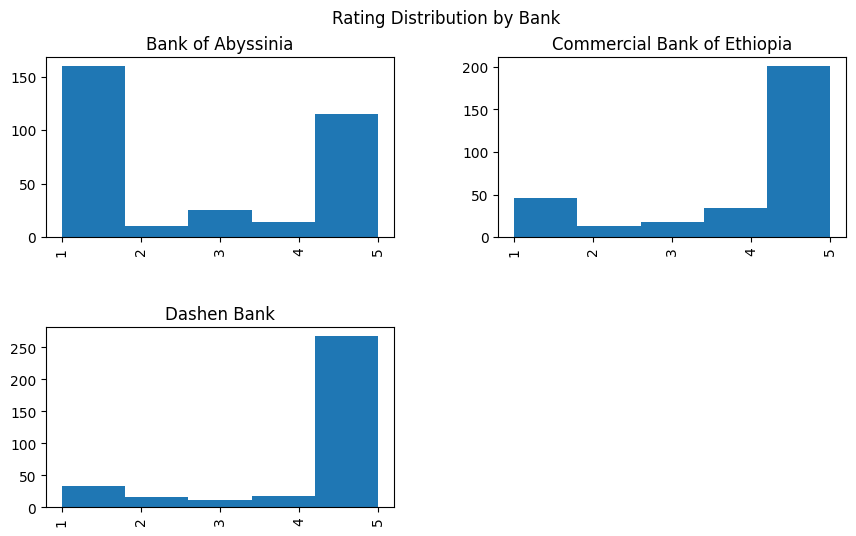

In [21]:
print(df['bank'].value_counts())
df['rating'].hist(by=df['bank'], bins=5, figsize=(10, 6))
plt.suptitle('Rating Distribution by Bank')
plt.show()
